# 8. Backward graph rollout — no RL

Start at the query $z^*$ and work **backward**. Each node picks a stencil *template*; its
neighbours become new nodes; repeat until every branch lands on the initial condition or a
boundary. Then evaluate **forward**.

- Cost = number of interior nodes (operator evaluations). Reusing an existing node is free.
- $\beta_n$ = influence of node $n$ on $\hat u(z^*)$, known the moment $n$ is reached.
- $\tau_n$ = node $n$'s own truncation error. Exactly: $\;\hat u(z^*) - u(z^*) = \sum_n \beta_n \tau_n$.

Here every policy is a hand-written rule, to see what this formulation can reach before any learning.

In [1]:
import heapq
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# u_t + c u_x = alpha u_xx on [0,1], homogeneous Dirichlet  (same problem as 6.3)
alpha, c = 0.1, 1.0
nx, T = 100, 0.5
dx = 1.0 / (nx - 1)
nt = max(int(np.ceil(T / min(0.9 * dx / c, 0.45 * dx**2 / alpha))) + 1, 10)
dt = T / (nt - 1)

# exact solution: u = exp(b x - alpha b^2 t) v,  v solves the heat equation
_xq = np.linspace(0, 1, 80001)
_b  = c / (2 * alpha)
_v0 = (np.sin(np.pi * _xq) + 0.5 * np.sin(2 * np.pi * _xq)) * np.exp(-_b * _xq)
_n  = np.arange(1, 801)
_bn = np.array([2 * np.trapezoid(_v0 * np.sin(k * np.pi * _xq), _xq) for k in _n])

def u_true(x, t):
    x = np.atleast_1d(np.asarray(x, float))
    v = (np.sin(np.pi * np.outer(x, _n)) * (_bn * np.exp(-alpha * (_n * np.pi)**2 * t))).sum(1)
    return np.exp(_b * x - alpha * _b**2 * t) * v

print(f"dx = {dx:.4g}, dt = {dt:.4g}, nt = {nt}")

dx = 0.0101, dt = 0.0004591, nt = 1090


## Operator and templates

A template is **3 points, $k$ levels below the node**, spread $\pm W$ cells and shifted $s$ cells.
With exactly 3 points the weights are unique, so $k=1$ *is* the FD stencil.

- $W$ is the smallest width keeping $\alpha k\Delta t/(W\Delta x)^2 \le \tfrac12$ → positive weights.
- $s$ defaults to the characteristic foot $-c\,k\Delta t/\Delta x$, rounded.
- If a template is invalid at a node (clipped by a boundary, or not all weights positive), fall
  back to the next smaller $k$. FD is always valid, so every stencil used has $\|w\|_1 = 1$.

In [2]:
LADDER = [1, 2, 4, 8, 16, 32]

def template(k, s=None):
    W = int(np.ceil(np.sqrt(2 * alpha * k * dt) / dx))
    s = -int(round(c * k * dt / dx)) if s is None else s
    return [(s - W, -k), (s, -k), (s + W, -k)]

def solve_weights(dxs, dts):
    h = max(np.abs(dxs).max(), np.sqrt(alpha * np.abs(dts).max()))
    A = np.array([np.ones(3), (dxs - c * dts) / h, (0.5 * dxs**2 + alpha * dts) / h**2])
    return np.linalg.lstsq(A, [1.0, 0.0, 0.0], rcond=None)[0]

exact = lambda n: n[1] == 0 or n[0] == 0 or n[0] == nx - 1

def stencil_for(n, choice):
    k, s = choice if isinstance(choice, tuple) else (choice, None)
    for kk, ss in [(k, s)] + [(j, None) for j in reversed(LADDER) if j <= k]:
        pts = [(n[0] + a, max(n[1] + b, 0)) for a, b in template(kk, ss)]
        if all(0 <= p[0] < nx for p in pts):                  # no boundary clipping
            w = solve_weights(np.array([p[0] - n[0] for p in pts]) * dx,
                              np.array([p[1] - n[1] for p in pts]) * dt)
            if w.min() >= -1e-12:                             # positive -> ||w||_1 = 1
                return pts, w, (kk, ss) != (k, s)
    raise RuntimeError(f"no valid stencil at {n}")

## Rollout: build backward, evaluate forward

In [3]:
def rollout(z, policy):
    beta, sten, falls = defaultdict(float), {}, 0
    beta[z] = 1.0
    heap, seen = [(-z[1], z)], {z}
    while heap:                                   # latest time first -> beta is complete
        _, n = heapq.heappop(heap)
        if exact(n):
            continue
        pts, w, fell = stencil_for(n, policy(n, beta[n], z))
        sten[n], falls = (pts, w), falls + fell
        for p, wi in zip(pts, w):
            beta[p] += beta[n] * wi
            if p not in seen:
                seen.add(p); heapq.heappush(heap, (-p[1], p))

    by_t = defaultdict(list)                      # exact values, vectorised per time level
    for n in seen:
        by_t[n[1]].append(n[0])
    ue = {}
    for it, ixs in by_t.items():
        ue.update(zip([(ix, it) for ix in ixs], u_true(np.array(ixs) * dx, it * dt)))

    u = {n: ue[n] for n in seen if exact(n)}
    tau = {}
    for n in sorted(sten, key=lambda n: n[1]):   # earliest time first
        pts, w = sten[n]
        u[n]   = w @ [u[p] for p in pts]
        tau[n] = w @ [ue[p] for p in pts] - ue[n]

    return dict(points=len(sten), err=abs(u[z] - ue[z]), signed=u[z] - ue[z],
                decomp=sum(beta[n] * tau[n] for n in sten), fallbacks=falls,
                beta=beta, sten=sten)

## Hand-written policies

A policy sees the node, its $\beta$, and the query, and returns a template ($k$, or $(k, s)$).

In [4]:
fd        = lambda n, b, z: 1
const     = lambda k: (lambda n, b, z: k)
fine_near = lambda n, b, z: max(k for k in LADDER if k <= max(1, (z[1] - n[1]) // 4))  # small k near z*
fine_ic   = lambda n, b, z: max(k for k in LADDER if k <= max(1, n[1] // 4))           # small k near t=0

POLICIES = {"FD (k=1)": fd, **{f"k={k}": const(k) for k in LADDER[1:]},
            "fine near z*": fine_near, "fine near IC": fine_ic}

## Results

In [5]:
X_STAR = 50
results = {}
for tstar in [75, 150]:
    print(f"\n t* = {tstar}  (x* = {X_STAR})")
    print(f"  {'policy':14s} {'points':>7s} {'error':>10s} {'sum beta*tau':>13s} {'fallbacks':>9s}")
    for name, pol in POLICIES.items():
        r = results[tstar, name] = rollout((X_STAR, tstar), pol)
        print(f"  {name:14s} {r['points']:7d} {r['err']:10.3e} {r['decomp']:+13.3e} {r['fallbacks']:9d}")


 t* = 75  (x* = 50)
  policy          points      error  sum beta*tau fallbacks
  FD (k=1)          4949  1.924e-04    +1.924e-04         0
  k=2               1457  2.722e-04    +2.722e-04        27
  k=4                361  7.599e-04    +7.599e-04         0
  k=8                100  1.435e-03    +1.435e-03         0
  k=16                25  7.513e-04    +7.513e-04         0
  k=32                 9  3.494e-03    +3.494e-03         0
  fine near z*       617  8.781e-04    +8.781e-04         0
  fine near IC       813  9.841e-04    +9.841e-04         0

 t* = 150  (x* = 50)
  policy          points      error  sum beta*tau fallbacks
  FD (k=1)         12299  3.642e-04    +3.642e-04         0
  k=2               5726  5.762e-04    +5.762e-04       107
  k=4               1680  1.449e-03    +1.449e-03        54
  k=8                452  2.815e-03    +2.815e-03        66
  k=16               100  2.316e-03    +2.316e-03         0
  k=32                25  7.689e-03    +7.689e-03        

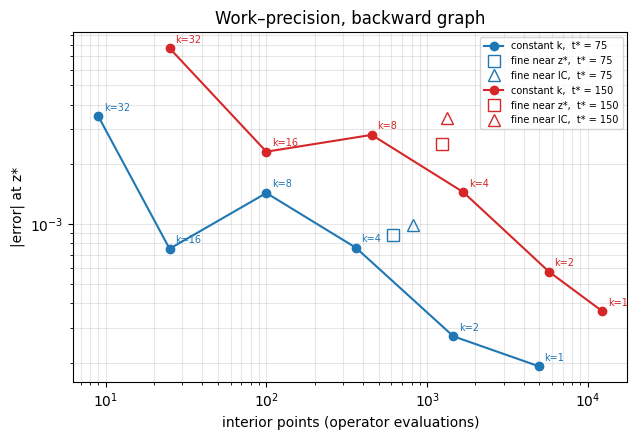

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for tstar, col in [(75, "C0"), (150, "C3")]:
    fam = ["FD (k=1)"] + [f"k={k}" for k in LADDER[1:]]
    ax.plot([results[tstar, f]["points"] for f in fam], [results[tstar, f]["err"] for f in fam],
            "o-", color=col, label=f"constant k,  t* = {tstar}")
    for f, k in zip(fam, LADDER):
        r = results[tstar, f]
        ax.annotate(f"k={k}", (r["points"], r["err"]), textcoords="offset points",
                    xytext=(4, 4), fontsize=7, color=col)
    for f, m in [("fine near z*", "s"), ("fine near IC", "^")]:
        r = results[tstar, f]
        ax.plot(r["points"], r["err"], m, color=col, mfc="none", ms=8,
                label=f"{f},  t* = {tstar}")
ax.set(xscale="log", yscale="log", xlabel="interior points (operator evaluations)",
       ylabel="|error| at z*", title="Work–precision, backward graph")
ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## Does following the characteristic matter?

For each $k$, try the two integer shifts that bracket the characteristic foot $-c\,k\Delta t/\Delta x$.

In [7]:
tstar = 75
print(f"  {'k':>3s} {'foot':>7s} {'s':>3s} {'points':>7s} {'error':>10s} {'fell back':>10s}")
for k in LADDER:
    foot = -c * k * dt / dx
    rows = [(s, rollout((X_STAR, tstar), lambda n, b, z, k=k, s=s: (k, s)))
            for s in sorted({int(np.floor(foot)), int(np.ceil(foot))})]
    best = min(r["err"] for _, r in rows)
    for s, r in rows:
        mark = "  <- better" if r["err"] == best and r["fallbacks"] < r["points"] else ""
        print(f"  {k:3d} {foot:7.3f} {s:3d} {r['points']:7d} {r['err']:10.3e} "
              f"{r['fallbacks']:4d}/{r['points']:<5d}{mark}")

    k    foot   s  points      error  fell back
    1  -0.045  -1    4949  1.924e-04 4949/4949 
    1  -0.045   0    4949  1.924e-04    0/4949   <- better
    2  -0.091  -1    1503  1.129e-03  137/1503 
    2  -0.091   0    1457  2.722e-04   27/1457   <- better
    4  -0.182  -1     361  6.765e-04  324/361    <- better
    4  -0.182   0     361  7.599e-04    0/361  
    8  -0.364  -1     100  5.864e-04    0/100    <- better
    8  -0.364   0     100  1.435e-03    0/100  
   16  -0.727  -1      25  7.513e-04    0/25     <- better
   16  -0.727   0      25  2.897e-03    0/25   
   32  -1.455  -2       9  1.903e-03    0/9      <- better
   32  -1.455  -1       9  3.494e-03    0/9    


## What the graph looks like

Colour = $\log_{10}\beta$. Dashed: characteristic through $z^*$. Dotted: $\pm\sqrt{2\alpha(t^*-t)}$ around it.

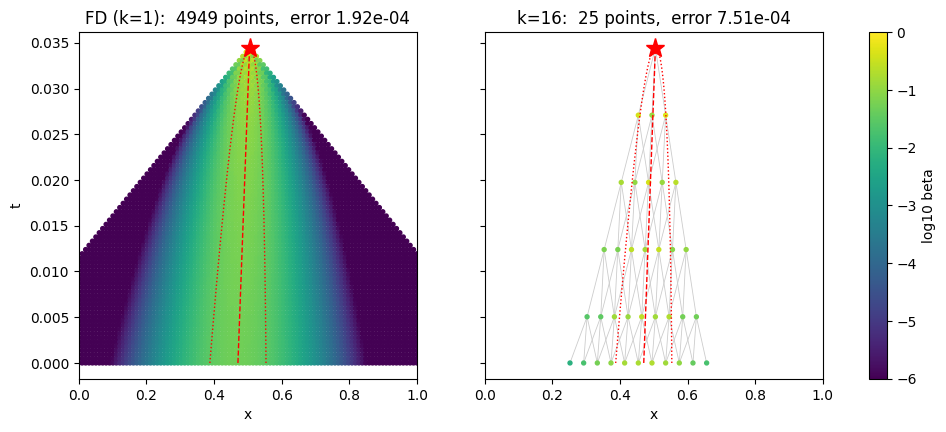

In [8]:
tstar = 75
z = (X_STAR, tstar)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, name in zip(axes, ["FD (k=1)", "k=16"]):
    r = results[tstar, name]
    nodes = [n for n in r["beta"] if r["beta"][n] > 0]
    if len(r["sten"]) < 500:
        for n, (pts, _) in r["sten"].items():
            for p in pts:
                ax.plot([n[0] * dx, p[0] * dx], [n[1] * dt, p[1] * dt], color="0.8", lw=0.6, zorder=0)
    sc = ax.scatter([n[0] * dx for n in nodes], [n[1] * dt for n in nodes], s=8,
                    c=np.log10([r["beta"][n] for n in nodes]), cmap="viridis", vmin=-6, vmax=0)
    tt = np.linspace(0, tstar * dt, 100)
    xc = X_STAR * dx - c * (tstar * dt - tt)
    ax.plot(xc, tt, "r--", lw=1)
    for sgn in (-1, 1):
        ax.plot(xc + sgn * np.sqrt(2 * alpha * (tstar * dt - tt)), tt, "r:", lw=1)
    ax.plot(X_STAR * dx, tstar * dt, "r*", ms=14)
    ax.set(xlim=(0, 1), xlabel="x",
           title=f"{name}:  {r['points']} points,  error {r['err']:.2e}")
axes[0].set_ylabel("t")
fig.colorbar(sc, ax=axes, label="log10 beta")
plt.show()

## Greedy template choice

At each node, try every template $(k, s)$ and keep the one with the cheapest **immediate** cost:

$$\text{cost} = |\beta_n \tau_n| \;+\; \lambda \cdot \text{(price of the new points it creates)}$$

Two ways to price a new point:
- **count** — every new point costs 1.
- **depth** — a new point costs its height above $t = 0$: a point high up will need a big subtree
  below it, one near the initial condition is almost free.

Greedy is short-sighted: it sees this node's error and the points it creates, not the subtree those
points will need later. Sweeping $\lambda$ traces a work–precision curve, compared against the best
constant template (each $k$ with its better shift).

In [9]:
def make_greedy(lam, depth=False):
    made, UE = set(), {}                          # points created so far, cached exact values
    def ue(p):
        if p not in UE:
            UE[p] = u_true(p[0] * dx, p[1] * dt)[0]
        return UE[p]
    def policy(n, b, z):
        made.add(z)
        best = None
        for k in LADDER:
            foot = -c * k * dt / dx
            for s in {int(np.floor(foot)), int(np.ceil(foot))}:
                pts, w, fell = stencil_for(n, (k, s))
                if fell:
                    continue
                tau = w @ [ue(p) for p in pts] - ue(n)
                new = [p for p in pts if p not in made]
                price = sum(p[1] for p in new) if depth else len(new)
                cost = abs(b * tau) + lam * price
                if best is None or cost < best[0]:
                    best = (cost, (k, s), pts)
        made.update(best[2])
        return best[1]
    return policy

In [10]:
tstar = 75
z = (X_STAR, tstar)

best_const = []                                   # each k with its better (valid) shift
for k in LADDER:
    foot = -c * k * dt / dx
    rs = [rollout(z, lambda n, b, zz, k=k, s=s: (k, s))
          for s in {int(np.floor(foot)), int(np.ceil(foot))}]
    best_const.append(min((r for r in rs if r["fallbacks"] < r["points"] / 2), key=lambda r: r["err"]))

greedy = {}
print(f"  {'variant':7s} {'lambda':>8s} {'points':>7s} {'error':>10s}")
for variant, lams in [("count", [0, 1e-7, 1e-6, 1e-5, 1e-4]),
                      ("depth", [1e-9, 1e-8, 1e-7, 1e-6, 1e-5])]:
    for lam in lams:
        r = greedy[variant, lam] = rollout(z, make_greedy(lam, variant == "depth"))
        print(f"  {variant:7s} {lam:8.0e} {r['points']:7d} {r['err']:10.3e}")

  variant   lambda  points      error
  count      0e+00    4785  1.634e-04
  count      1e-07    4718  1.893e-04
  count      1e-06    4480  1.592e-04
  count      1e-05    4362  1.893e-04
  count      1e-04    4362  1.893e-04
  depth      1e-09    2502  1.683e-04
  depth      1e-08    1798  1.424e-04
  depth      1e-07     479  1.315e-04
  depth      1e-06      78  7.550e-04
  depth      1e-05      13  1.420e-03


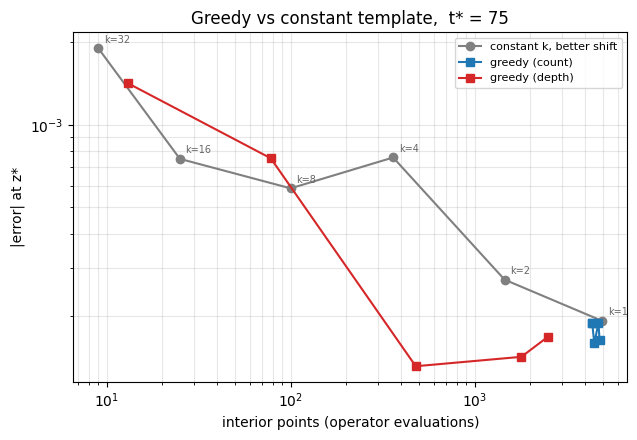

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot([r["points"] for r in best_const], [r["err"] for r in best_const], "o-", color="0.5",
        label="constant k, better shift")
for r, k in zip(best_const, LADDER):
    ax.annotate(f"k={k}", (r["points"], r["err"]), textcoords="offset points", xytext=(4, 4),
                fontsize=7, color="0.4")
for variant, col in [("count", "C0"), ("depth", "C3")]:
    rs = sorted((r for (v, _), r in greedy.items() if v == variant), key=lambda r: r["points"])
    ax.plot([r["points"] for r in rs], [r["err"] for r in rs], "s-", color=col, label=f"greedy ({variant})")
ax.set(xscale="log", yscale="log", xlabel="interior points (operator evaluations)",
       ylabel="|error| at z*", title=f"Greedy vs constant template,  t* = {tstar}")
ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Where did greedy take big steps? Nodes of its most accurate run, coloured by the step size
actually used.

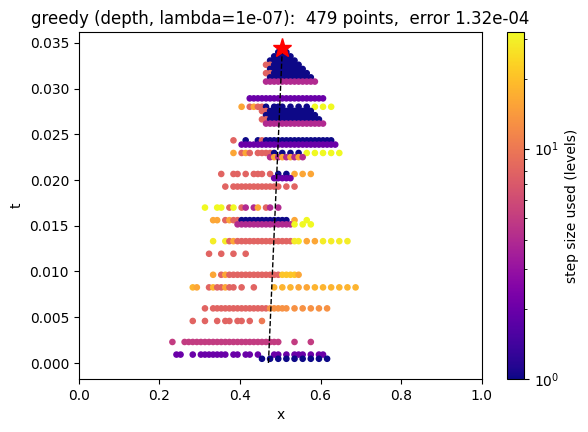

In [12]:
from matplotlib.colors import LogNorm

(variant, lam), r = min(greedy.items(), key=lambda kv: kv[1]["err"])
nodes = list(r["sten"])
step = [n[1] - r["sten"][n][0][1][1] for n in nodes]      # height drop to the middle neighbour

fig, ax = plt.subplots(figsize=(6.5, 4.5))
sc = ax.scatter([n[0] * dx for n in nodes], [n[1] * dt for n in nodes], s=14, c=step,
                cmap="plasma", norm=LogNorm(1, 32))
tt = np.linspace(0, tstar * dt, 100)
ax.plot(X_STAR * dx - c * (tstar * dt - tt), tt, "k--", lw=1)
ax.plot(X_STAR * dx, tstar * dt, "r*", ms=14)
ax.set(xlim=(0, 1), xlabel="x", ylabel="t",
       title=f"greedy ({variant}, lambda={lam:.0e}):  {r['points']} points,  error {r['err']:.2e}")
fig.colorbar(sc, label="step size used (levels)")
plt.show()